# Amazon E-commerce Product Performance & Pricing Analytics

**Goal:** Analyze product ratings, reviews, monthly purchases, pricing, discounts, Best Seller status, sponsorship, coupons, Buy Box availability, delivery details, and sustainability badges.

**Libraries:** Pandas, NumPy, Matplotlib, Seaborn, Plotly

Place your CSV file in the same folder as this notebook and name it `amazon_products.csv`, or change `FILE_PATH` below.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


In [18]:
FILE_PATH = "/content/amazon_sales_data_uncleaned.csv"
df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (42675, 13)


,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges
0,"BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wir...",4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Charging Cable 6.6FT, Chubby USB A/C to C/Lightning ...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wireless Lavalier Microphone, Intelligent Noise Cancell...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN
3,"Apple AirPods Pro 2 Wireless Earbuds, Active Noise Cancellation, Hearing Aid Feature, Bluetooth ...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN
4,"Apple AirTag 4 Pack. Keep Track of and find Your Keys, Wallet, Luggage, Backpack, and More. Simp...",4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN


## 1. Data Understanding

In [19]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nSummary:")
display(df.describe(include="all").T)


Rows: 42675
Columns: 13

Columns:
['Title', 'Rating', 'Number_of_reviews', 'bought_in_last_month', 'Current/discounted_price', 'Price_on_variant', 'Listed_price', 'is_best_seller', 'is_sponsored', 'is_couponed', 'buy_box_availability', 'delivery_details', 'sustainability_badges']

Data types:


,dtype
Title,object
Rating,object
Number_of_reviews,object
bought_in_last_month,object
Current/discounted_price,object
Price_on_variant,object
Listed_price,object
is_best_seller,object
is_sponsored,object
is_couponed,object



Summary:


,count,unique,top,freq
Title,42675,8808,"Duracell Coppertop 9V Battery, 6 Count (Pack of 1), 9 Volt Battery with Long-lasting Power, All-...",744
Rating,41651,31,4.6 out of 5 stars,6151
Number_of_reviews,41651,4413,25,626
bought_in_last_month,39458,59,100+ bought in past month,8801
Current/discounted_price,30926,2576,29.99,825
Price_on_variant,42675,3466,basic variant price: nan,21031
Listed_price,42675,911,No Discount,30364
is_best_seller,42675,12,No Badge,40814
is_sponsored,42675,2,Organic,35664
is_couponed,42675,42,No Coupon,40727


## 2. Data Cleaning

In [20]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace("-", "_")
)

print(df.columns.tolist())

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().copy()
print("Shape after duplicates:", df.shape)


['title', 'rating', 'number_of_reviews', 'bought_in_last_month', 'current_discounted_price', 'price_on_variant', 'listed_price', 'is_best_seller', 'is_sponsored', 'is_couponed', 'buy_box_availability', 'delivery_details', 'sustainability_badges']
Duplicate rows: 32602
Shape after duplicates: (10073, 13)


In [21]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_pct", ascending=False)
)
display(missing)


,missing_count,missing_pct
sustainability_badges,9210,91.432542
buy_box_availability,3474,34.488236
delivery_details,2937,29.157153
current_discounted_price,2934,29.127370
bought_in_last_month,267,2.650650
number_of_reviews,86,0.853767
rating,86,0.853767
title,0,0.000000
price_on_variant,0,0.000000
is_sponsored,0,0.000000


In [22]:
numeric_cols = [
    "rating", "number_of_reviews", "bought_in_last_month",
    "current_discounted_price", "price_on_variant", "listed_price"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.replace(r"[^0-9.\-]", "", regex=True)
            .replace("", np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
rating,9987.0,4.487559,0.307650,1.05,4.350,4.55,4.650,5.05
number_of_reviews,9987.0,5746.200360,23037.954875,1.00,178.000,839.00,3517.000,865598.00
bought_in_last_month,8738.0,200.000343,201.924312,1.00,10.000,100.00,300.000,900.00
current_discounted_price,7139.0,183.681855,359.118792,2.49,25.630,69.99,179.990,4699.00
price_on_variant,5722.0,184.904530,378.833378,1.00,25.935,69.99,170.255,5449.00
listed_price,3302.0,177.218755,360.634789,4.95,28.990,69.99,183.910,5399.00


In [23]:
boolean_cols = [
    "is_best_seller", "is_sponsored", "is_couponed", "buy_box_availability"
]

def to_bool(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"true", "yes", "y", "1", "available", "in stock"}:
        return True
    if s in {"false", "no", "n", "0", "unavailable", "not available"}:
        return False
    return x

for col in boolean_cols:
    if col in df.columns:
        df[col] = df[col].map(to_bool)

display(df[boolean_cols].head())


,is_best_seller,is_sponsored,is_couponed,buy_box_availability
0,No Badge,Sponsored,Save 15% with coupon,Add to cart
1,No Badge,Sponsored,No Coupon,Add to cart
2,No Badge,Sponsored,No Coupon,Add to cart
3,Best Seller,Organic,No Coupon,NaN
4,No Badge,Organic,No Coupon,NaN


## 3. Feature Engineering

In [24]:
df["discount_amount"] = df["listed_price"] - df["current_discounted_price"]

df["discount_percentage"] = np.where(
    df["listed_price"] > 0,
    df["discount_amount"] / df["listed_price"] * 100,
    np.nan
)

df["price_difference_variant"] = df["listed_price"] - df["price_on_variant"]

df["reviews_per_monthly_purchase"] = np.where(
    df["bought_in_last_month"] > 0,
    df["number_of_reviews"] / df["bought_in_last_month"],
    np.nan
)

df.loc[(df["discount_percentage"] < 0) | (df["discount_percentage"] > 100),
       "discount_percentage"] = np.nan

df["rating_category"] = pd.cut(
    df["rating"],
    bins=[0, 3, 4, 4.5, 5],
    labels=["Poor", "Average", "Good", "Excellent"],
    include_lowest=True
)

df["discount_category"] = pd.cut(
    df["discount_percentage"],
    bins=[-0.01, 10, 20, 30, 40, 100],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40%+"],
    include_lowest=True
)

display(df.head())


,title,rating,number_of_reviews,bought_in_last_month,current_discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,discount_amount,discount_percentage,price_difference_variant,reviews_per_monthly_purchase,rating_category,discount_category
0,"BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wir...",4.65,375.0,300.0,89.68,2.40,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,69.32,43.597484,156.6,1.25,Excellent,40%+
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Charging Cable 6.6FT, Chubby USB A/C to C/Lightning ...",4.35,2457.0,6.0,9.99,NaN,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,6.00,37.523452,NaN,409.50,Good,30-40%
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wireless Lavalier Microphone, Intelligent Noise Cancell...",4.65,3044.0,2.0,314.00,NaN,349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,35.00,10.028653,NaN,1522.00,Excellent,10-20%
3,"Apple AirPods Pro 2 Wireless Earbuds, Active Noise Cancellation, Hearing Aid Feature, Bluetooth ...",4.65,35882.0,10.0,NaN,162.24,NaN,Best Seller,Organic,No Coupon,NaN,NaN,NaN,NaN,NaN,NaN,3588.20,Excellent,NaN
4,"Apple AirTag 4 Pack. Keep Track of and find Your Keys, Wallet, Luggage, Backpack, and More. Simp...",4.85,28988.0,10.0,NaN,72.74,NaN,No Badge,Organic,No Coupon,NaN,NaN,NaN,NaN,NaN,NaN,2898.80,Excellent,NaN


## 4. KPI Overview

In [25]:
kpis = {
    "Total Products": len(df),
    "Total Reviews": df["number_of_reviews"].sum(),
    "Total Monthly Purchases": df["bought_in_last_month"].sum(),
    "Average Rating": df["rating"].mean(),
    "Average Current Price": df["current_discounted_price"].mean(),
    "Average Discount %": df["discount_percentage"].mean()
}

display(pd.Series(kpis).to_frame("Value"))


,Value
Total Products,1.007300e+04
Total Reviews,5.738730e+07
Total Monthly Purchases,1.747603e+06
Average Rating,4.487559e+00
Average Current Price,1.836819e+02
Average Discount %,2.123136e+01


## 5. Exploratory Data Analysis

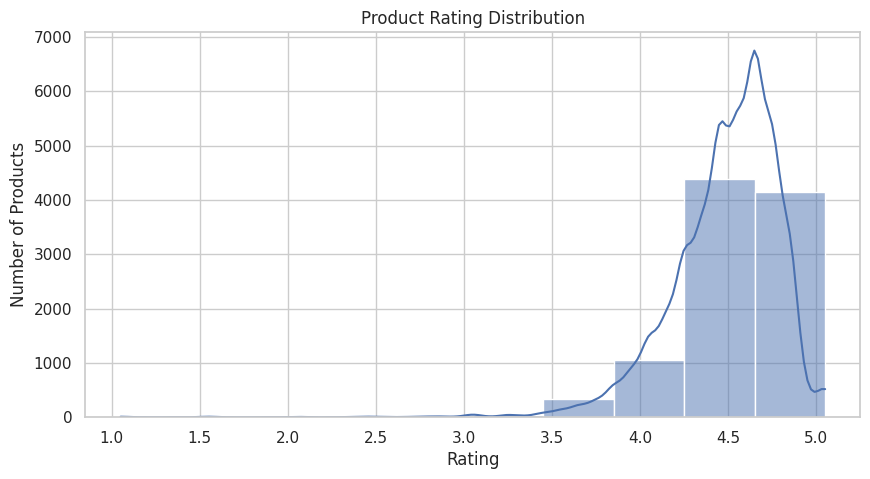

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df["rating"].dropna(), bins=10, kde=True)
plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()


,title,rating,number_of_reviews,bought_in_last_month,current_discounted_price
895,"HP LaserJet Pro MFP 4101fdw Wireless Black & White All-in-One Laser Printer, Scanner, Copier, Fa...",4.25,460.0,900.0,559.00
1172,"HP 210X Yellow High-Yield Toner Cartridge | Works Color Laserjet Pro 4201, Color Laserjet Pro MF...",4.65,77.0,900.0,255.99
1266,"HP 414X Magenta High-yield Toner Cartridge | Works with HP Color LaserJet Enterprise M455dn, MFP...",4.75,650.0,900.0,307.89
1300,"HP Smart Tank 6001 Wireless All-in-One Refillable Ink Tank Printer, Scanner, Copier with 2 years...",3.85,2646.0,900.0,NaN
1664,"HP 712 29ml Cyan DesignJet Original Ink Cartridge for T650, T630, T230, T210 & Studio Plotter Pr...",4.65,178.0,900.0,NaN
1814,HP Smart Tank 7602 Wireless All-in-One Ink Tank Printer with up to 2 years of ink included (28B98A),4.05,1578.0,900.0,NaN
1990,"Amazon Basics Mesh Mid-Back Adjustable-Height 360-Degree Swivel Office Desk Chair with Armrests,...",4.35,16662.0,900.0,86.04
2133,"Brother TN436BK Super High Yield Toner-Retail Packaging , Black",4.75,1077.0,900.0,102.99
2148,"Fellowes Saturn 3i 125 Thermal Laminator Machine for Home or Office with Pouch Starter Kit, 12.5...",4.55,1933.0,900.0,109.99
2296,"Cardo Systems Spirit HD Motorcycle Bluetooth Communication Headset, 2-Way Bluetooth, Thin 40mm S...",4.55,4711.0,900.0,161.96


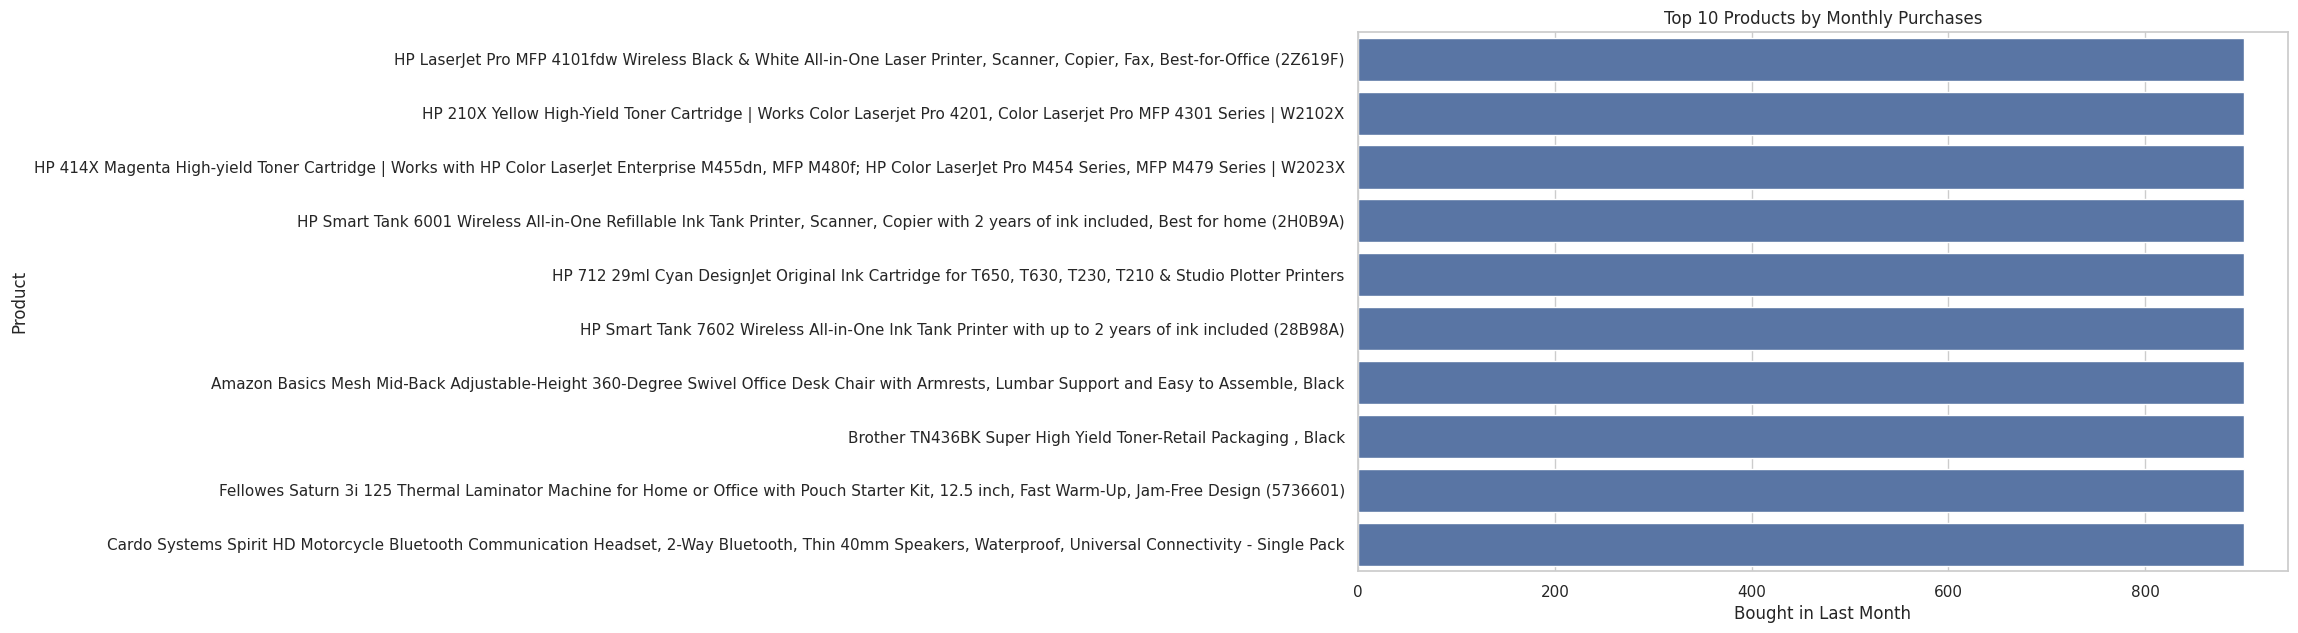

In [27]:
top10 = df.nlargest(10, "bought_in_last_month").copy()

display(top10[[
    "title", "rating", "number_of_reviews",
    "bought_in_last_month", "current_discounted_price"
]])

plt.figure(figsize=(12, 7))
sns.barplot(data=top10, x="bought_in_last_month", y="title")
plt.title("Top 10 Products by Monthly Purchases")
plt.xlabel("Bought in Last Month")
plt.ylabel("Product")
plt.show()


In [28]:
top_reviews = df.nlargest(10, "number_of_reviews")
display(top_reviews[[
    "title", "number_of_reviews", "rating", "bought_in_last_month"
]])


,title,number_of_reviews,rating,bought_in_last_month
10,"Amazon Basics 48-Pack AA Alkaline High-Performance Batteries, 1.5 Volt, 10-Year Shelf Life",865598.0,4.75,100.0
8565,"SanDisk 32GB Ultra microSDHC UHS-I Memory Card with Adapter - 98MB/s, C10, U1, Full HD, A1, Micr...",645418.0,4.75,1.0
8909,[Older Version] SanDisk 32GB 2-Pack Ultra MicroSDHC UHS-I Memory Card (2x32GB) - SDSQUAR-032G-GN6MT,645416.0,4.75,400.0
17,"Amazon Basics AAA Alkaline High-Performance Batteries, 1.5 Volt, 10-Year Shelf Life, 36 Count (P...",625776.0,4.75,100.0
695,"Amazon Basics HDMI Cable, 3ft, 4K@60Hz, High-Speed 4K HDMI 2.0 Cord (18Gbps), 2160p, 48 bit, Com...",553927.0,4.75,10.0
4486,"Amazon Fire TV Stick, sharp picture quality, fast streaming, free & live TV, Alexa Voice Remote ...",517617.0,4.75,500.0
3100,"SanDisk 1TB Extreme microSDXC UHS-I Memory Card with Adapter - Up to 160MB/s, C10, U3, V30, 4K, ...",353306.0,4.85,500.0
4024,"[Older Version] SanDisk 128GB Ultra microSDXC UHS-I Memory Card with Adapter - 120MB/s, C10, U1,...",315834.0,4.75,1.0
750,"Blink Mini - Compact indoor plug-in smart security camera, 1080p HD video, night vision, motion ...",302790.0,4.45,6.0
7868,SanDisk Cruzer Blade 8GB USB 2.0 Flash Drive- SDCZ50-008G-B35,298061.0,4.65,500.0


## 6. Rating vs Purchases

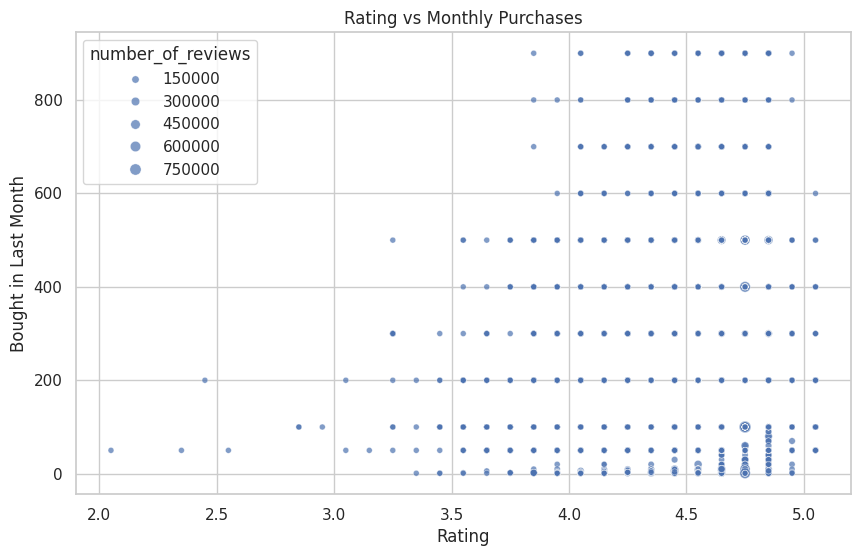

Correlation between rating and monthly purchases: 0.015


In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="rating",
    y="bought_in_last_month",
    size="number_of_reviews",
    alpha=0.7
)
plt.title("Rating vs Monthly Purchases")
plt.xlabel("Rating")
plt.ylabel("Bought in Last Month")
plt.show()

corr_rating = df[["rating", "bought_in_last_month"]].corr().iloc[0, 1]
print(f"Correlation between rating and monthly purchases: {corr_rating:.3f}")


## 7. Pricing & Discount Analysis

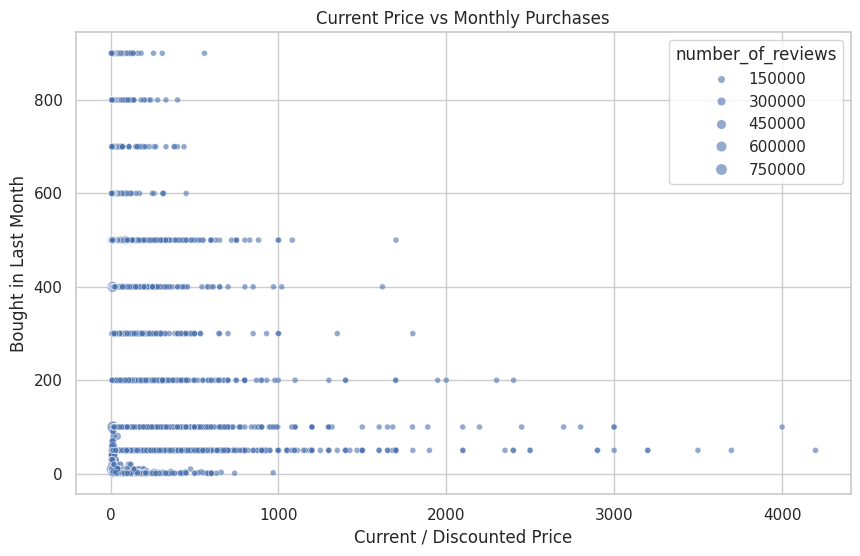

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="current_discounted_price",
    y="bought_in_last_month",
    size="number_of_reviews",
    alpha=0.6
)
plt.title("Current Price vs Monthly Purchases")
plt.xlabel("Current / Discounted Price")
plt.ylabel("Bought in Last Month")
plt.show()


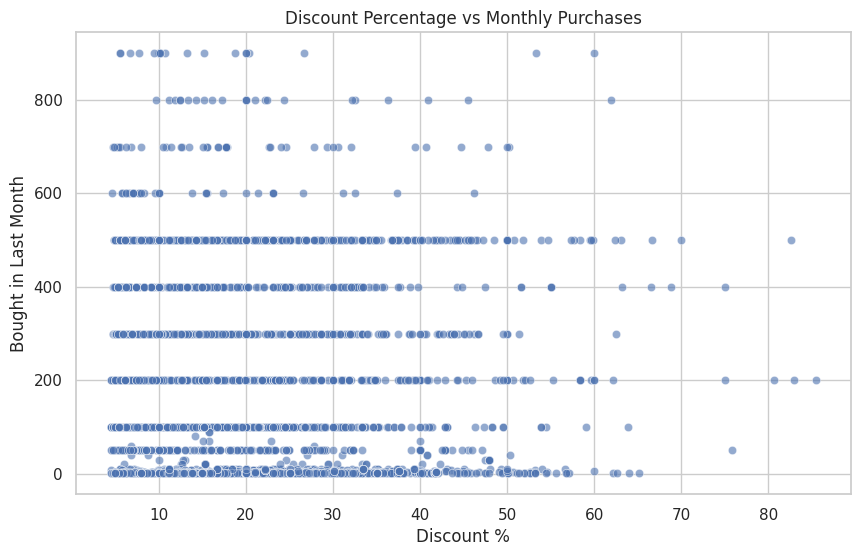

Correlation between discount percentage and monthly purchases: -0.063


In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="discount_percentage",
    y="bought_in_last_month",
    alpha=0.6
)
plt.title("Discount Percentage vs Monthly Purchases")
plt.xlabel("Discount %")
plt.ylabel("Bought in Last Month")
plt.show()

corr_discount = df[["discount_percentage", "bought_in_last_month"]].corr().iloc[0, 1]
print(f"Correlation between discount percentage and monthly purchases: {corr_discount:.3f}")


,discount_category,products,avg_purchases,avg_rating,avg_discount
0,0-10%,631,241.511945,4.506418,7.166998
1,10-20%,1106,201.392823,4.518739,14.330342
2,20-30%,812,190.217722,4.503770,24.083477
3,30-40%,443,180.761337,4.492045,33.904600
4,40%+,310,189.256849,4.505844,48.899026


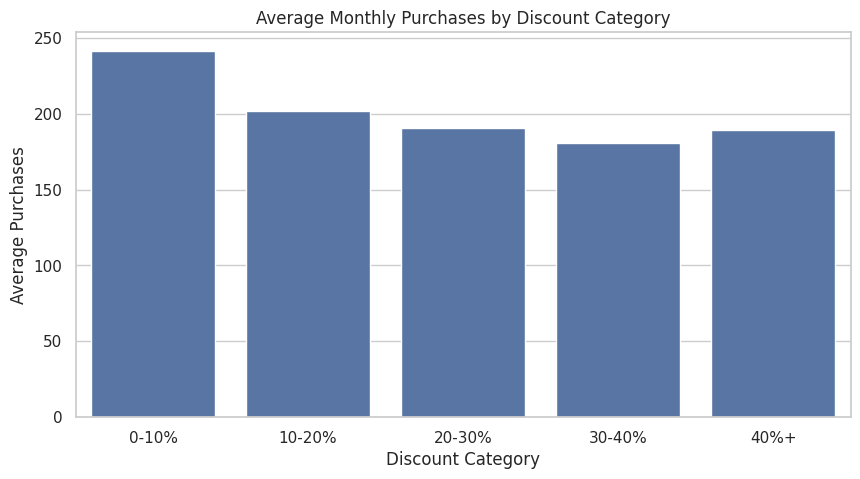

In [32]:
discount_analysis = (
    df.groupby("discount_category", observed=True)
      .agg(
          products=("title", "count"),
          avg_purchases=("bought_in_last_month", "mean"),
          avg_rating=("rating", "mean"),
          avg_discount=("discount_percentage", "mean")
      )
      .reset_index()
)

display(discount_analysis)

plt.figure(figsize=(10, 5))
sns.barplot(data=discount_analysis, x="discount_category", y="avg_purchases")
plt.title("Average Monthly Purchases by Discount Category")
plt.xlabel("Discount Category")
plt.ylabel("Average Purchases")
plt.show()


## 8. Best Seller Analysis

In [33]:
best_seller_analysis = (
    df.groupby("is_best_seller", dropna=False)
      .agg(
          products=("title", "count"),
          avg_rating=("rating", "mean"),
          avg_reviews=("number_of_reviews", "mean"),
          avg_purchases=("bought_in_last_month", "mean"),
          avg_price=("current_discounted_price", "mean"),
          avg_discount=("discount_percentage", "mean")
      )
      .reset_index()
)

display(best_seller_analysis)


,is_best_seller,products,avg_rating,avg_reviews,avg_purchases,avg_price,avg_discount
0,Amazon's,343,4.570700,6746.965015,173.816199,139.603733,20.979240
1,Best Seller,227,4.582599,34283.414097,85.886878,70.354888,24.951573
2,Ends in,2,4.450000,1256.500000,350.000000,71.345000,12.692641
3,Limited time deal,33,4.665625,4538.125000,110.370370,115.879697,29.869223
4,No Badge,9455,4.481515,5031.016862,204.472124,188.513475,21.021961
5,Save 10%,1,4.250000,72.000000,NaN,1579.990000,9.714341
6,Save 12%,2,4.350000,195.000000,50.000000,579.000000,12.139605
7,Save 17%,1,4.450000,50.000000,100.000000,149.990000,16.667593
8,Save 18%,1,4.350000,57.000000,50.000000,899.990000,18.181983
9,Save 30%,2,4.350000,246.000000,100.000000,139.950000,30.007502


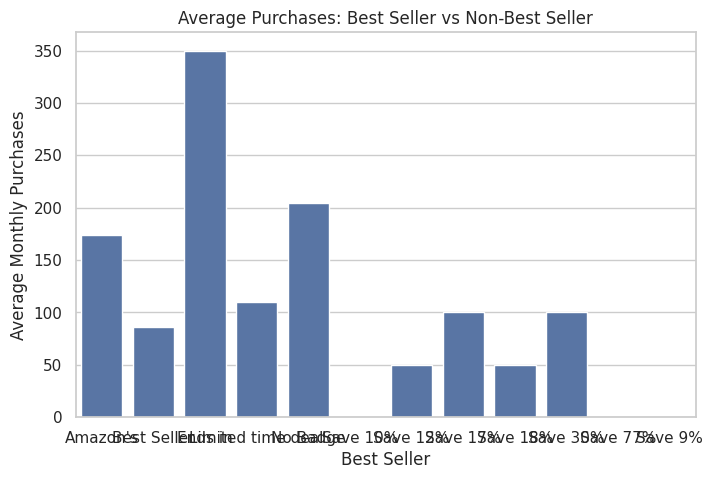

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(data=best_seller_analysis, x="is_best_seller", y="avg_purchases")
plt.title("Average Purchases: Best Seller vs Non-Best Seller")
plt.xlabel("Best Seller")
plt.ylabel("Average Monthly Purchases")
plt.show()


## 9. Sponsored Product Analysis

In [35]:
sponsored_analysis = (
    df.groupby("is_sponsored", dropna=False)
      .agg(
          products=("title", "count"),
          avg_purchases=("bought_in_last_month", "mean"),
          avg_rating=("rating", "mean"),
          avg_reviews=("number_of_reviews", "mean"),
          avg_price=("current_discounted_price", "mean"),
          avg_discount=("discount_percentage", "mean")
      )
      .reset_index()
)

display(sponsored_analysis)


,is_sponsored,products,avg_purchases,avg_rating,avg_reviews,avg_price,avg_discount
0,Organic,9320,205.767476,4.491268,5671.078201,183.625830,20.924769
1,Sponsored,753,95.013187,4.439525,6718.906425,184.161971,23.588893


## 10. Coupon Analysis

In [36]:
coupon_analysis = (
    df.groupby("is_couponed", dropna=False)
      .agg(
          products=("title", "count"),
          avg_purchases=("bought_in_last_month", "mean"),
          avg_rating=("rating", "mean"),
          avg_reviews=("number_of_reviews", "mean"),
          avg_discount=("discount_percentage", "mean")
      )
      .reset_index()
)

display(coupon_analysis)


,is_couponed,products,avg_purchases,avg_rating,avg_reviews,avg_discount
0,No Coupon,9791,200.286033,4.489586,5794.315497,21.264002
1,Save $0.33 with coupon,1,20.000000,4.850000,26634.000000,25.420561
2,Save $1.00 with coupon,4,127.500000,4.625000,5039.000000,15.568159
3,Save $1.50 with coupon,2,2.500000,4.450000,29576.500000,NaN
4,Save $10.00 with coupon,8,337.500000,4.112500,4144.125000,11.006412
5,Save $100.00 with coupon,5,125.000000,4.330000,75.600000,NaN
6,Save $11.00 with coupon,10,400.000000,4.340000,469.200000,NaN
7,Save $12.00 with coupon,3,366.666667,4.250000,133.333333,NaN
8,Save $120.00 with coupon,1,NaN,3.050000,1.000000,NaN
9,Save $13.00 with coupon,1,50.000000,4.050000,40.000000,NaN


## 11. Buy Box Analysis

In [37]:
buybox_analysis = (
    df.groupby("buy_box_availability", dropna=False)
      .agg(
          products=("title", "count"),
          avg_purchases=("bought_in_last_month", "mean"),
          avg_rating=("rating", "mean"),
          avg_reviews=("number_of_reviews", "mean"),
          avg_price=("current_discounted_price", "mean")
      )
      .reset_index()
)

display(buybox_analysis)


,buy_box_availability,products,avg_purchases,avg_rating,avg_reviews,avg_price
0,Add to cart,6599,205.327597,4.507235,6210.051851,184.588470
1,NaN,3474,187.271140,4.450261,4866.913308,173.872699


## 12. Sustainability Badge Analysis

In [38]:
if "sustainability_badges" in df.columns:
    df["has_sustainability_badge"] = (
        df["sustainability_badges"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .astype(int)
    )

    sustainability_analysis = (
        df.groupby("has_sustainability_badge")
          .agg(
              products=("title", "count"),
              avg_rating=("rating", "mean"),
              avg_purchases=("bought_in_last_month", "mean"),
              avg_reviews=("number_of_reviews", "mean"),
              avg_price=("current_discounted_price", "mean")
          )
          .reset_index()
    )

    display(sustainability_analysis)
else:
    print("Column sustainability_badges not found.")


,has_sustainability_badge,products,avg_rating,avg_purchases,avg_reviews,avg_price
0,0,9210,4.492098,201.848032,5107.303266,189.792533
1,1,863,4.439571,182.512575,12500.889919,118.627553


## 13. Correlation Analysis

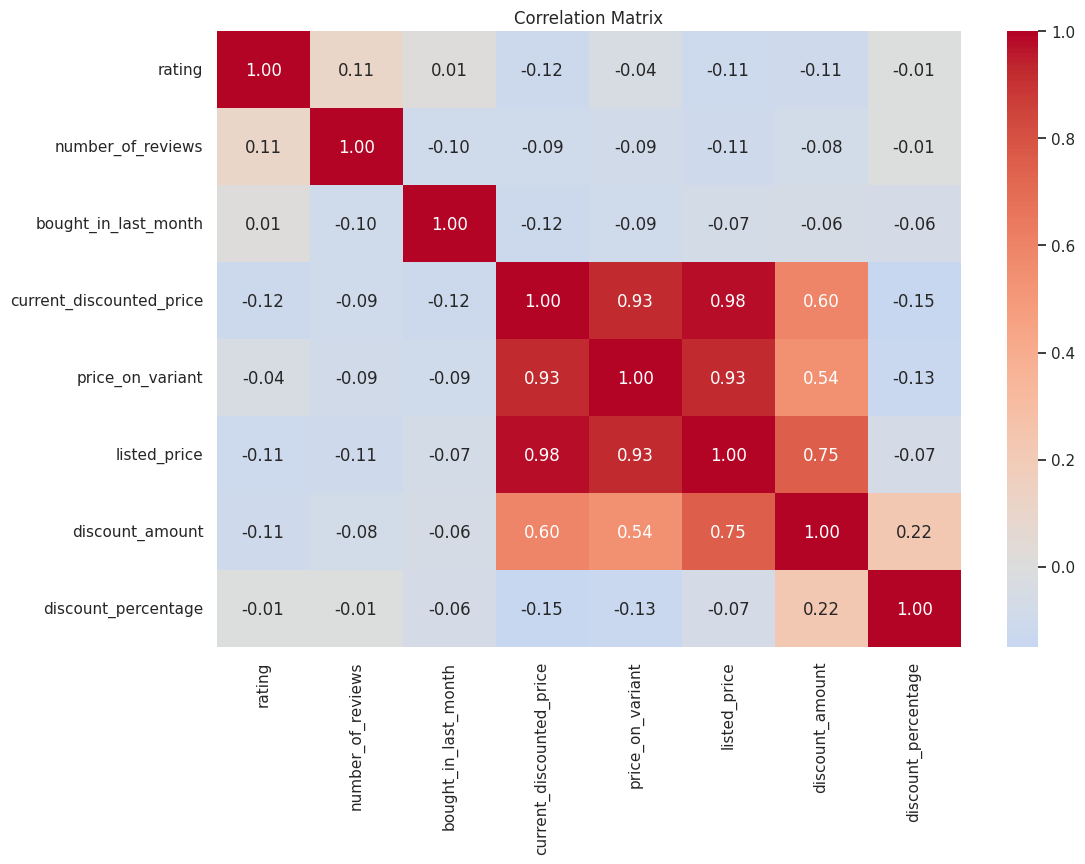

,rating,number_of_reviews,bought_in_last_month,current_discounted_price,price_on_variant,listed_price,discount_amount,discount_percentage
rating,1.000000,0.107580,0.014792,-0.118824,-0.040307,-0.112259,-0.105170,-0.006588
number_of_reviews,0.107580,1.000000,-0.095865,-0.094021,-0.092103,-0.105082,-0.080243,-0.005167
bought_in_last_month,0.014792,-0.095865,1.000000,-0.115791,-0.093164,-0.071205,-0.058561,-0.062644
current_discounted_price,-0.118824,-0.094021,-0.115791,1.000000,0.925748,0.978578,0.597983,-0.151065
price_on_variant,-0.040307,-0.092103,-0.093164,0.925748,1.000000,0.927364,0.543410,-0.130736
listed_price,-0.112259,-0.105082,-0.071205,0.978578,0.927364,1.000000,0.750186,-0.067667
discount_amount,-0.105170,-0.080243,-0.058561,0.597983,0.543410,0.750186,1.000000,0.221748
discount_percentage,-0.006588,-0.005167,-0.062644,-0.151065,-0.130736,-0.067667,0.221748,1.000000


In [39]:
corr_cols = [
    "rating", "number_of_reviews", "bought_in_last_month",
    "current_discounted_price", "price_on_variant", "listed_price",
    "discount_amount", "discount_percentage"
]

corr_cols = [c for c in corr_cols if c in df.columns]
correlation = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

display(correlation)


## 14. Product Performance Score

In [40]:
# Portfolio metric combining rating, reviews and monthly purchases.
df["performance_score"] = (
    df["rating"].fillna(df["rating"].median()) * 20
    + np.log1p(df["number_of_reviews"].clip(lower=0).fillna(0)) * 10
    + np.log1p(df["bought_in_last_month"].clip(lower=0).fillna(0)) * 15
)

top_performers = df.nlargest(10, "performance_score")

display(top_performers[[
    "title", "rating", "number_of_reviews",
    "bought_in_last_month", "performance_score"
]])


,title,rating,number_of_reviews,bought_in_last_month,performance_score
4486,"Amazon Fire TV Stick, sharp picture quality, fast streaming, free & live TV, Alexa Voice Remote ...",4.75,517617.0,500.0,319.819019
8909,[Older Version] SanDisk 32GB 2-Pack Ultra MicroSDHC UHS-I Memory Card (2x32GB) - SDSQUAR-032G-GN6MT,4.75,645416.0,400.0,318.685940
3100,"SanDisk 1TB Extreme microSDXC UHS-I Memory Card with Adapter - Up to 160MB/s, C10, U3, V30, 4K, ...",4.85,353306.0,500.0,318.000018
7868,SanDisk Cruzer Blade 8GB USB 2.0 Flash Drive- SDCZ50-008G-B35,4.65,298061.0,500.0,312.299659
3942,"Kingston 960GB A400 SATA3 2.5"" Internal SSD SA400S37/960G - HDD Replacement for Increase Perform...",4.75,199598.0,500.0,310.289748
7738,HP Printer Paper | 8.5 x 11 Paper | Office 20 lb | 1 Ream - 500 Sheets | 92 Bright | Made in USA...,4.85,117666.0,600.0,309.735063
4030,Apple AirTag 4 Pack,4.85,140716.0,500.0,308.794152
5283,"Roku Premiere | HD/4K/HDR Streaming Media Player, Simple Remote and Premium HDMI Cable, Black",4.75,95192.0,500.0,302.885708
5904,"Melissa & Doug Solar System Floor Puzzle (48 pcs, 2 x 3 Feet) - FSC Certified",4.85,30468.0,900.0,302.297229
8898,"[Older Version] SanDisk 64GB Extreme PRO SDXC UHS-I Card - C10, U3, V30, 4K UHD, SD Card - SDSDX...",4.85,157355.0,300.0,302.269314


## 15. Interactive Plotly Visualizations

In [42]:
import pandas as pd
import plotly.express as px

# Convert columns to numeric
df["current_discounted_price"] = pd.to_numeric(
    df["current_discounted_price"], errors="coerce"
)

df["bought_in_last_month"] = pd.to_numeric(
    df["bought_in_last_month"], errors="coerce"
)

df["number_of_reviews"] = pd.to_numeric(
    df["number_of_reviews"], errors="coerce"
)

df["rating"] = pd.to_numeric(
    df["rating"], errors="coerce"
)

# Remove rows where important plotting values are missing
plot_df = df.dropna(
    subset=[
        "current_discounted_price",
        "bought_in_last_month",
        "number_of_reviews",
        "rating"
    ]
)

fig = px.scatter(
    plot_df,
    x="current_discounted_price",
    y="bought_in_last_month",
    size="number_of_reviews",
    color="rating",
    hover_name="title",
    title="Price vs Monthly Purchases",
    template="plotly_white"
)

fig.show()

In [43]:
top20 = df.nlargest(20, "bought_in_last_month").sort_values("bought_in_last_month")

fig = px.bar(
    top20,
    x="bought_in_last_month",
    y="title",
    orientation="h",
    color="rating",
    hover_data=["number_of_reviews", "current_discounted_price"],
    title="Top 20 Products by Monthly Purchases",
    template="plotly_white"
)
fig.show()


## 16. Business Questions

Use the outputs above to answer:

1. Which products have the highest monthly purchase volume?
2. Does a higher rating correspond to higher purchases?
3. Does a larger discount correspond to higher purchases?
4. Do Best Seller products have higher average reviews and purchases?
5. Do sponsored products perform better than non-sponsored products?
6. Do couponed products have higher average purchases?
7. Does Buy Box availability appear associated with higher purchases?
8. Are sustainability-badge products different in rating, price, or purchases?
9. Which numerical variables have the strongest correlation with monthly purchases?
10. Which products are the strongest overall performers?

**Note:** Correlation does not prove causation. Use phrases such as *associated with* or *correlated with* when presenting findings.


In [44]:
print("===== BUSINESS SUMMARY =====")
print(f"Total products: {len(df):,}")
print(f"Total monthly purchases: {df['bought_in_last_month'].sum():,.0f}")
print(f"Average rating: {df['rating'].mean():.2f}")
print(f"Average discount: {df['discount_percentage'].mean():.2f}%")

if df["bought_in_last_month"].notna().any():
    best = df.loc[df["bought_in_last_month"].idxmax()]
    print(f"Top product by monthly purchases: {best['title']}")
    print(f"Monthly purchases: {best['bought_in_last_month']:,.0f}")

print(f"Rating-purchase correlation: {df[['rating', 'bought_in_last_month']].corr().iloc[0,1]:.3f}")
print(f"Discount-purchase correlation: {df[['discount_percentage', 'bought_in_last_month']].corr().iloc[0,1]:.3f}")


===== BUSINESS SUMMARY =====
Total products: 10,073
Total monthly purchases: 1,747,603
Average rating: 4.49
Average discount: 21.23%
Top product by monthly purchases: HP LaserJet Pro MFP 4101fdw Wireless Black & White All-in-One Laser Printer, Scanner, Copier, Fax, Best-for-Office (2Z619F)
Monthly purchases: 900
Rating-purchase correlation: 0.015
Discount-purchase correlation: -0.063
